# U-Net — Instance Segmentation + Detection
### DeepFashion2 – Top-5 Categories

**Prerequisite:** Run `preprocessing.ipynb` first.

**Pipeline:**
1. U-Net outputs per-pixel class predictions (semantic segmentation)
2. Connected Component Analysis separates instances
3. Bounding boxes extracted from each connected component
4. Category labels assigned via majority voting

## 1. Setup

In [1]:
# Kaggle: no drive mount needed
import os
SAVE_DIR = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Save dir:", SAVE_DIR)

Save dir: /kaggle/working/VR_Mini_Project-1


In [2]:
!pip install pycocotools -q

In [3]:
import shutil

DRIVE_SAVE = "/kaggle/working/VR_Mini_Project-1"
shutil.copy(
    "/kaggle/input/datasets/sasank2035/unet-weights-transfer/unet_transfer.pth",
    f"{DRIVE_SAVE}/unet_scratch.pth"
)
print("Weights copied to working dir ✓")

Weights copied to working dir ✓


In [4]:
import os, json, random, time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from tqdm.notebook import tqdm
from sklearn.metrics import (
    precision_recall_fscore_support, roc_curve, auc as sk_auc
)

# ---- Global constants ----
TOP5           = [1, 8, 7, 2, 9]
category_names = ['Short Sleeve Top', 'Trousers', 'Shorts', 'Long Sleeve Top', 'Skirt']
cat_to_idx     = {cat_id: i + 1 for i, cat_id in enumerate(TOP5)}
idx_to_name    = {0: 'Background', **{i+1: n for i, n in enumerate(category_names)}}
NUM_CLASSES    = len(TOP5) + 1
IMG_SIZE       = 256  # 256 vs 512: 4x fewer pixels → ~4x faster per epoch

DRIVE_SAVE = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(DRIVE_SAVE, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print('Device:', device)
print(f'GPUs available: {n_gpus}')
print('cat_to_idx:', cat_to_idx)

Device: cuda
GPUs available: 2
cat_to_idx: {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}


## 2. Dataset

In [5]:
class DeepFashionSegDataset(Dataset):
    """
    Returns:
      image : FloatTensor [3, H, W]  (normalised)
      mask  : LongTensor  [H, W]     (pixel class labels 0..NUM_CLASSES-1)
    """

    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, image_dir, anno_dir, img_size=IMG_SIZE, augment=False):
        self.image_dir = image_dir
        self.img_size  = img_size
        self.augment   = augment
        self.images    = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

        # Pre-parse annotation JSON dicts (lightweight — strings/ints only, no pixel arrays)
        self.annos = []
        for img_name in self.images:
            anno_path = os.path.join(anno_dir, img_name.replace('.jpg', '.json'))
            if os.path.exists(anno_path):
                with open(anno_path) as f:
                    self.annos.append(json.load(f))
            else:
                self.annos.append({})

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        data     = self.annos[idx]

        # Load + resize image with cv2 (faster than PIL for JPEG)
        img = cv2.imread(os.path.join(self.image_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H0, W0 = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

        # Build mask at original resolution, then resize once
        seg_mask = np.zeros((H0, W0), dtype=np.uint8)
        for key in data:
            if not key.startswith('item'): continue
            cat_id = data[key]['category_id']
            if cat_id not in cat_to_idx: continue
            label = cat_to_idx[cat_id]
            for poly in data[key]['segmentation']:
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(seg_mask, [np.ascontiguousarray(pts)], int(label))
        seg_mask = cv2.resize(seg_mask, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_NEAREST)

        # Augmentation
        if self.augment and random.random() < 0.5:
            img      = img[:, ::-1, :].copy()
            seg_mask = seg_mask[:, ::-1].copy()

        # Normalise: HWC uint8 → CHW float32
        img_t = torch.from_numpy(img.copy()).permute(2, 0, 1).float().div_(255.0)
        mean  = torch.as_tensor(self.IMAGENET_MEAN).view(3, 1, 1)
        std   = torch.as_tensor(self.IMAGENET_STD).view(3, 1, 1)
        img_t = img_t.sub_(mean).div_(std)

        mask_t = torch.from_numpy(seg_mask.astype(np.int64))
        return img_t, mask_t, img_name

In [17]:
import gc  # needed for VRAM cleanup

BASE = "/kaggle/input/datasets/sasank93/vr-mini-project-pruned"

train_full = DeepFashionSegDataset(f"{BASE}/pruned_train/images",
                                   f"{BASE}/pruned_train/annos", augment=True)
val_full   = DeepFashionSegDataset(f"{BASE}/pruned_val/images",
                                   f"{BASE}/pruned_val/annos",   augment=False)
test_ds    = DeepFashionSegDataset(f"{BASE}/pruned_test/images",
                                   f"{BASE}/pruned_test/annos",  augment=False)

np.random.seed(42)
train_ds = Subset(train_full,
                  np.random.choice(len(train_full), int(len(train_full)*0.3), replace=False))
val_ds   = Subset(val_full,
                  np.random.choice(len(val_full),   int(len(val_full)*0.3),   replace=False))

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

_nw = 4
# FIX: prefetch_factor reduced 3→2 to avoid overfilling pinned CPU/GPU memory
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=_nw, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2,
                          drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=_nw, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=_nw, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

Train: 36764 | Val: 7122 | Test: 21627


## 3. U-Net Architecture (ResNet-34 Encoder)

In [7]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        self.conv = ConvBnRelu(out_c + skip_c, out_c)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class UNetResNet34(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        enc = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT if pretrained else None)
        self.enc0       = nn.Sequential(enc.conv1, enc.bn1, enc.relu)
        self.pool       = enc.maxpool
        self.enc1       = enc.layer1
        self.enc2       = enc.layer2
        self.enc3       = enc.layer3
        self.enc4       = enc.layer4
        self.bottleneck = ConvBnRelu(512, 512)
        self.dec4       = DecoderBlock(512, 256, 256)
        self.dec3       = DecoderBlock(256, 128, 128)
        self.dec2       = DecoderBlock(128,  64,  64)
        self.dec1       = DecoderBlock( 64,  64,  64)
        self.dec0_conv  = ConvBnRelu(64, 32)
        self.head       = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        s0 = self.enc0(x)
        s1 = self.enc1(self.pool(s0))
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        x  = self.bottleneck(s4)
        x  = self.dec4(x, s3)
        x  = self.dec3(x, s2)
        x  = self.dec2(x, s1)
        x  = self.dec1(x, s0)
        x  = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x  = self.dec0_conv(x)
        return self.head(x)


_m = UNetResNet34(NUM_CLASSES, pretrained=False)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
_o = _m(_x)
print('Output shape:', _o.shape)  # expect [2, 6, 256, 256]
del _m, _x, _o


Output shape: torch.Size([2, 6, 256, 256])


## 4. Loss Function (Dice + Cross-Entropy)

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=None, smooth=1.0):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)          # [B, C, H, W]
        n, c  = probs.shape[:2]

        # One-hot: [B, H, W, C] → [B, C, H, W]
        t_oh = F.one_hot(targets.clamp(0, c - 1), c).permute(0, 3, 1, 2).float()

        # Flatten spatial dims: [B, C, H*W]
        p_flat = probs.flatten(2)
        t_flat = t_oh.flatten(2)

        inter = (p_flat * t_flat).sum(2)           # [B, C]
        denom = p_flat.sum(2) + t_flat.sum(2)      # [B, C]
        dice  = (2 * inter + self.smooth) / (denom + self.smooth)  # [B, C]

        if self.ignore_index is not None:
            mask = torch.ones(c, device=logits.device, dtype=torch.bool)
            mask[self.ignore_index] = False
            dice = dice[:, mask]

        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """0.5 * CrossEntropy + 0.5 * Dice."""
    def __init__(self, num_classes, class_weights=None):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss(num_classes)

    def forward(self, logits, targets):
        return 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets)


def compute_class_weights(loader, num_classes, device, max_batches=200):
    """Compute inverse-frequency class weights for CrossEntropy."""
    counts = torch.zeros(num_classes)
    for i, (_, masks, _) in enumerate(tqdm(loader, desc='Computing class weights')):
        # Vectorised bincount — much faster than a Python loop over classes
        counts += torch.bincount(masks.flatten(), minlength=num_classes).float()
        if i >= max_batches:
            break
    counts  = counts.clamp(min=1)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes
    print("Class weights:", weights)
    return weights.to(device)


class_weights = compute_class_weights(train_loader, NUM_CLASSES, device)
criterion = CombinedLoss(NUM_CLASSES, class_weights=class_weights)

Computing class weights:   0%|          | 0/1148 [00:00<?, ?it/s]

Class weights: tensor([0.0630, 0.4774, 1.0380, 1.9294, 0.8950, 1.5972])


## 5. Training

In [11]:
from torch.amp import GradScaler, autocast

torch.backends.cudnn.benchmark = True


def train_unet(model, train_loader, val_loader, criterion, save_path,
               device, num_epochs=15, lr=1e-4, patience=5):
    """
    VRAM-safe training loop.
    Fixes applied vs original:
      1. del batch tensors after every step (train + val)
      2. gc.collect() + empty_cache() after each full epoch loop
      3. Early stopping (patience) to bail before a late-epoch OOM
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = GradScaler('cuda')

    best_val_loss     = 0.6
    epochs_no_improve = 0
    history           = {'train': [], 'val': []}

    for epoch in range(1, num_epochs + 1):

        # ── TRAIN ────────────────────────────────────────────────
        model.train()
        t_loss = 0.0
        t0     = time.time()

        for imgs, masks, _ in tqdm(train_loader, desc=f'[E{epoch}/{num_epochs}] Train'):
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda'):
                logits = model(imgs)
                loss   = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()

            # FIX 1: .item() detaches from compute graph; immediately free tensors
            t_loss += loss.item()
            del imgs, masks, logits, loss

        t_loss /= len(train_loader)

        # FIX 2: full cache flush after the train loop
        gc.collect()
        torch.cuda.empty_cache()

        # ── VALIDATE ─────────────────────────────────────────────
        model.eval()
        v_loss = 0.0

        with torch.no_grad():
            for imgs, masks, _ in tqdm(val_loader, desc=f'[E{epoch}/{num_epochs}] Val'):
                imgs  = imgs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                with autocast('cuda'):
                    logits = model(imgs)
                    loss   = criterion(logits, masks)
                v_loss += loss.item()
                del imgs, masks, logits, loss  # FIX 1 (val loop)

        v_loss /= len(val_loader)

        # FIX 2: full cache flush after the val loop
        gc.collect()
        torch.cuda.empty_cache()

        scheduler.step()
        history['train'].append(t_loss)
        history['val'].append(v_loss)
        print(f'Epoch {epoch:3d} | Train={t_loss:.4f} | Val={v_loss:.4f} '
              f'| LR={scheduler.get_last_lr()[0]:.2e} | {time.time()-t0:.0f}s')

        # ── CHECKPOINT + EARLY STOPPING ──────────────────────────
        if v_loss < best_val_loss:
            print(f'  ✓ Improved {best_val_loss:.4f} → {v_loss:.4f}. Saving.')
            best_val_loss = v_loss
            epochs_no_improve = 0
            state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
            torch.save(state, save_path)
        else:
            epochs_no_improve += 1
            print(f'  No improvement for {epochs_no_improve}/{patience} epoch(s).')
            # FIX 3: early stopping prevents late-epoch OOM
            if epochs_no_improve >= patience:
                print(f'\n  Early stopping triggered at epoch {epoch}.')
                break

    print(f'\nBest val loss: {best_val_loss:.4f}')
    return history


### 5a. Train from Scratch

In [11]:
print('\n=== U-NET: TRAINING FROM SCRATCH ===')
model_scratch = UNetResNet34(NUM_CLASSES, pretrained=False).to(device)
if n_gpus > 1:
    model_scratch = nn.DataParallel(model_scratch)

# ── Resume from checkpoint if one exists ──────────────────────────────────────
_scratch_path = f"{DRIVE_SAVE}/unet_scratch.pth"
_scratch_start_epoch = 1
if os.path.exists(_scratch_path):
    print(f"  ✓ Found checkpoint at {_scratch_path}. Resuming...")
    _state = torch.load(_scratch_path, map_location=device)
    if hasattr(model_scratch, 'module'):
        model_scratch.module.load_state_dict(_state)
    else:
        model_scratch.load_state_dict(_state)
    print("  Weights loaded. Training will continue from the saved best weights.")
else:
    print("  No checkpoint found. Training from scratch.")
# ──────────────────────────────────────────────────────────────────────────────

hist_scratch = train_unet(
    model_scratch, train_loader, val_loader, criterion,
    save_path=_scratch_path,
    device=device, num_epochs=7, lr=1e-3, patience=5
)


=== U-NET: TRAINING FROM SCRATCH ===
  ✓ Found checkpoint at /kaggle/working/VR_Mini_Project-1/unet_scratch.pth. Resuming...
  Weights loaded. Training will continue from the saved best weights.


[E1/7] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

[E1/7] Val:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch   1 | Train=0.6698 | Val=0.6969 | LR=9.50e-04 | 1181s
  ✓ Improved inf → 0.6969. Saving.


[E2/7] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

...

[E6/7] Val:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch   6 | Train=0.4993 | Val=0.6439 | LR=4.95e-05 | 1192s
  No improvement for 1/5 epoch(s).


[E7/7] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

[E7/7] Val:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch   7 | Train=0.4736 | Val=0.6711 | LR=0.00e+00 | 1190s
  No improvement for 2/5 epoch(s).

Best val loss: 0.6408


In [ ]:
# FIX 5: Explicitly free scratch model before loading transfer model
del model_scratch
gc.collect()
torch.cuda.empty_cache()
print('VRAM cleared. Ready for transfer learning model.')

### 5b. Transfer Learning

In [ ]:
print('\n=== U-NET: TRANSFER LEARNING ===')
model_transfer = UNetResNet34(NUM_CLASSES, pretrained=True).to(device)
if n_gpus > 1:
    model_transfer = nn.DataParallel(model_transfer)

# ── Resume from checkpoint if one exists ──────────────────────────────────────
_transfer_path = f"{DRIVE_SAVE}/unet_transfer.pth"
if os.path.exists(_transfer_path):
    print(f"  ✓ Found checkpoint at {_transfer_path}. Resuming...")
    _state = torch.load(_transfer_path, map_location=device)
    if hasattr(model_transfer, 'module'):
        model_transfer.module.load_state_dict(_state)
    else:
        model_transfer.load_state_dict(_state)
    print("  Weights loaded. Training will continue from the saved best weights.")
else:
    print("  No checkpoint found. Training from ImageNet pretrained weights.")
# ──────────────────────────────────────────────────────────────────────────────

hist_transfer = train_unet(
    model_transfer, train_loader, val_loader, criterion,
    save_path=_transfer_path,
    device=device, num_epochs=10, lr=3.45e-05, patience=5
)


=== U-NET: TRANSFER LEARNING ===
  ✓ Found checkpoint at /kaggle/working/VR_Mini_Project-1/unet_transfer.pth. Resuming...
  Weights loaded. Training will continue from the saved best weights.


[E1/10] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

[E1/10] Val:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch   1 | Train=0.2193 | Val=0.6679 | LR=3.37e-05 | 1192s
  No improvement for 1/5 epoch(s).


[E2/10] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

...

[E4/10] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

[E4/10] Val:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch   4 | Train=0.1352 | Val=0.7845 | LR=2.26e-05 | 1177s
  No improvement for 4/5 epoch(s).


[E5/10] Train:   0%|          | 0/1148 [00:00<?, ?it/s]

[E5/10] Val:   0%|          | 0/223 [00:00<?, ?it/s]

## 6. Post-Processing: Instances from Semantic Masks

In [25]:
from scipy import ndimage as ndi

def extract_instances_from_semantic(pred_mask, min_area=200):
    """
    Input:  pred_mask [H, W] with class labels 0..NUM_CLASSES-1
    Output: list of dicts {
        'label': int,          # class index (1-indexed, 0=background)
        'bbox':  [x1,y1,x2,y2],
        'mask':  np.ndarray bool [H, W]
    }
    """
    H, W      = pred_mask.shape
    instances = []

    for cls in range(1, NUM_CLASSES):   # skip background
        binary = (pred_mask == cls).astype(np.uint8)
        if binary.sum() == 0:
            continue

        # Connected Component Analysis
        n_comp, labels_cc = cv2.connectedComponents(binary)

        for comp_id in range(1, n_comp):
            comp_mask = (labels_cc == comp_id)
            if comp_mask.sum() < min_area:
                continue

            # Bounding box from component
            ys, xs = np.where(comp_mask)
            x1, y1 = int(xs.min()), int(ys.min())
            x2, y2 = int(xs.max()), int(ys.max())

            instances.append({
                'label': cls,
                'bbox':  [x1, y1, x2, y2],
                'mask':  comp_mask,
            })

    return instances

## 7. Evaluation on Test Set

In [26]:
# =========================================================
# 7a. Pixel-Level mIoU + Dice (semantic)
# =========================================================

def evaluate_semantic(model, loader, device, num_classes, split_name="Test"):
    """Per-class pixel IoU and Dice (semantic segmentation metrics)."""
    model.eval()
    iou_sum  = torch.zeros(num_classes)
    dice_sum = torch.zeros(num_classes)
    counts   = torch.zeros(num_classes)

    with torch.no_grad():
        for imgs, masks_gt, _ in tqdm(loader, desc=f"Semantic eval [{split_name}]"):
            imgs = imgs.to(device, non_blocking=True)
            with autocast("cuda"):
                logits = model(imgs)
            preds    = logits.argmax(dim=1).cpu()   # [B, H, W]
            masks_gt = masks_gt.cpu()

            for c in range(num_classes):
                pm = (preds    == c)
                gm = (masks_gt == c)
                has_gt = gm.any(dim=(1, 2))
                has_pd = pm.any(dim=(1, 2))
                valid  = (has_gt | has_pd)
                if not valid.any(): continue

                inter = (pm & gm).flatten(1).sum(1).float()
                union = (pm | gm).flatten(1).sum(1).float()
                p_sum = pm.flatten(1).sum(1).float()
                g_sum = gm.flatten(1).sum(1).float()

                iou_sum[c]  += (inter[valid] / (union[valid] + 1e-7)).sum()
                dice_sum[c] += (2 * inter[valid] / (p_sum[valid] + g_sum[valid] + 1e-7)).sum()
                counts[c]   += valid.sum()

    print("\n" + "="*60)
    print(f"SEMANTIC SEG mIoU & Dice – {split_name}")
    print("="*60)
    ious, dices = [], []
    for c in range(num_classes):
        if counts[c] > 0:
            iou_c  = (iou_sum[c]  / counts[c]).item()
            dice_c = (dice_sum[c] / counts[c]).item()
            ious.append(iou_c); dices.append(dice_c)
            print(f"  {idx_to_name.get(c, str(c)):<20}: IoU={iou_c:.4f}  Dice={dice_c:.4f}")
    print("-"*60)
    fg_ious  = ious[1:] if len(ious) > 1 else ious
    fg_dices = dices[1:] if len(dices) > 1 else dices
    print(f"  Macro mIoU (FG) : {np.mean(fg_ious):.4f}")
    print(f"  Macro Dice (FG) : {np.mean(fg_dices):.4f}")
    return np.mean(fg_ious), np.mean(fg_dices)

In [27]:
# =========================================================
# 7b. Instance-level mIoU + Dice + Detection mAP
# =========================================================
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as coco_mask_utils
from PIL import Image


def evaluate_instance(model, test_ds, device, iou_thresh=0.5):
    """
    Run instance extraction on test set.
    Returns (gt_dict, pred_anns) for COCO eval and raw lists for mIoU/ROC.
    """
    model.eval()
    gt_anns, pred_anns = [], []
    gt_imgs = []
    ann_id  = 1

    n_cls    = len(category_names)
    y_true   = {cls: [] for cls in range(1, n_cls + 1)}
    y_scores = {cls: [] for cls in range(1, n_cls + 1)}
    y_pred   = {cls: [] for cls in range(1, n_cls + 1)}

    all_gt_inst   = []
    all_pred_inst = []

    with torch.no_grad():
        for idx in tqdm(range(len(test_ds)), desc="Instance eval"):
            img_t, mask_gt, img_name = test_ds[idx]

            with autocast("cuda"):
                logits = model(img_t.unsqueeze(0).to(device))
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()
            gt_mask   = mask_gt.numpy()

            H, W = pred_mask.shape
            gt_imgs.append({'id': idx, 'height': H, 'width': W})

            # --- GT instances from annotation polygons ---
            anno_path = os.path.join(
                "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos",
                img_name.replace('.jpg', '.json'))
            gt_instances = []
            gt_cls_set   = set()

            if os.path.exists(anno_path):
                with open(anno_path) as f:
                    data = json.load(f)

                orig_img = Image.open(os.path.join(
                    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images",
                    img_name))
                ow, oh = orig_img.size
                sx, sy = W / ow, H / oh

                for key in data:
                    if not key.startswith('item'): continue
                    cat_id = data[key]['category_id']
                    if cat_id not in cat_to_idx: continue
                    label = cat_to_idx[cat_id]
                    gt_cls_set.add(label)

                    bm = np.zeros((H, W), dtype=np.uint8)
                    for poly in data[key]['segmentation']:
                        pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                        pts[:, 0] *= sx
                        pts[:, 1] *= sy
                        pts = np.ascontiguousarray(pts.astype(np.int32))
                        cv2.fillPoly(bm, [pts], 1)

                    x1b, y1b, x2b, y2b = data[key]['bounding_box']
                    x1b = min(W-1, max(0, int(x1b * sx)))
                    y1b = min(H-1, max(0, int(y1b * sy)))
                    x2b = min(W,   max(0, int(x2b * sx)))
                    y2b = min(H,   max(0, int(y2b * sy)))

                    rle = coco_mask_utils.encode(np.asfortranarray(bm))
                    rle['counts'] = rle['counts'].decode('utf-8')
                    gt_anns.append({
                        'id': ann_id, 'image_id': idx,
                        'category_id': label,
                        'bbox': [float(x1b), float(y1b),
                                 float(x2b - x1b), float(y2b - y1b)],
                        'area': float((x2b - x1b) * (y2b - y1b)),
                        'iscrowd': 0, 'segmentation': rle
                    })
                    gt_instances.append({'label': label, 'mask': bm.astype(bool)})
                    ann_id += 1

            # --- Predicted instances via connected components ---
            pred_instances = extract_instances_from_semantic(pred_mask)

            for inst in pred_instances:
                x1, y1, x2, y2 = inst['bbox']
                roi_h = max(1, y2 - y1)
                roi_w = max(1, x2 - x1)
                conf  = min(float(inst['mask'].sum()) / (roi_h * roi_w + 1e-7), 1.0)

                m_bin = inst['mask'].astype(np.uint8)
                rle   = coco_mask_utils.encode(np.asfortranarray(m_bin))
                rle['counts'] = rle['counts'].decode('utf-8')
                pred_anns.append({
                    'image_id': idx,
                    'category_id': inst['label'],
                    'bbox': [float(x1), float(y1),
                             float(x2 - x1), float(y2 - y1)],
                    'score': conf,
                    'segmentation': rle
                })

            # ROC bookkeeping
            pred_cls_confs = {cls: 0.0 for cls in range(1, n_cls + 1)}
            for inst in pred_instances:
                cls  = inst['label']
                conf = float(inst['mask'].sum()) / (H * W + 1e-7)
                pred_cls_confs[cls] = max(pred_cls_confs[cls], conf)

            for cls in range(1, n_cls + 1):
                y_true[cls].append(1 if cls in gt_cls_set else 0)
                y_scores[cls].append(pred_cls_confs[cls])
                y_pred[cls].append(1 if pred_cls_confs[cls] > 0 else 0)

            all_gt_inst.append(gt_instances)
            all_pred_inst.append(pred_instances)

    cats    = [{'id': cls, 'name': idx_to_name[cls]} for cls in range(1, n_cls + 1)]
    gt_dict = {'images': gt_imgs, 'annotations': gt_anns, 'categories': cats}

    return gt_dict, pred_anns, y_true, y_scores, y_pred, all_gt_inst, all_pred_inst

In [28]:
# =========================================================
# RUN ALL EVALUATIONS
# =========================================================
from torch.amp import autocast
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

BEST_WEIGHTS = f"{DRIVE_SAVE}/unet_transfer.pth"

eval_model = UNetResNet34(NUM_CLASSES, pretrained=False).to(device)
eval_model.load_state_dict(torch.load(BEST_WEIGHTS, map_location=device))
if n_gpus > 1:
    eval_model = nn.DataParallel(eval_model)
eval_model.eval()

# --- Semantic mIoU & Dice ---
evaluate_semantic(eval_model, test_loader, device, NUM_CLASSES)

# --- Instance-level evaluation ---
print("\nExtracting instances and computing COCO mAP / ROC ...")
(gt_dict, pred_anns,
 y_true, y_scores, y_pred,
 all_gt_inst, all_pred_inst) = evaluate_instance(eval_model, test_ds, device)

Semantic eval [Test]:   0%|          | 0/676 [00:00<?, ?it/s]


SEMANTIC SEG mIoU & Dice – Test
  Background          : IoU=0.9007  Dice=0.9423
  Short Sleeve Top    : IoU=0.5593  Dice=0.6152
  Trousers            : IoU=0.6051  Dice=0.6787
  Shorts              : IoU=0.5111  Dice=0.5867
  Long Sleeve Top     : IoU=0.4324  Dice=0.4797
  Skirt               : IoU=0.4831  Dice=0.5360
------------------------------------------------------------
  Macro mIoU (FG) : 0.5182
  Macro Dice (FG) : 0.5793

Extracting instances and computing COCO mAP / ROC ...


Instance eval:   0%|          | 0/21627 [00:00<?, ?it/s]

In [29]:
# COCO mAP – bounding box
print("\n" + "="*60)
print("DETECTION mAP (COCO bbox)")
print("="*60)
coco_gt = COCO(); coco_gt.dataset = gt_dict; coco_gt.createIndex()
coco_dt = coco_gt.loadRes(pred_anns)
ev = COCOeval(coco_gt, coco_dt, iouType='bbox')
ev.evaluate(); ev.accumulate(); ev.summarize()

# COCO mAP – segmentation
print("\n" + "="*60)
print("SEGMENTATION mAP (COCO segm)")
print("="*60)
ev2 = COCOeval(coco_gt, coco_dt, iouType='segm')
ev2.evaluate(); ev2.accumulate(); ev2.summarize()


DETECTION mAP (COCO bbox)
creating index...
index created!
Loading and preparing results...
DONE (t=0.08s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=14.22s).
Accumulating evaluation results...
DONE (t=3.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.416
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.668
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.446
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.037
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.344
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.526
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.600
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.605
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.605
 Averag


DETECTION: Per-Class P / R / F1 / AUC
  Short Sleeve Top    : P=0.7816 R=0.9265 F1=0.8479 AUC=0.8815
  Trousers            : P=0.8688 R=0.9437 F1=0.9047 AUC=0.9483
  Shorts              : P=0.8166 R=0.9053 F1=0.8587 AUC=0.9287
  Long Sleeve Top     : P=0.6580 R=0.8550 F1=0.7436 AUC=0.8718
  Skirt               : P=0.7050 R=0.8764 F1=0.7814 AUC=0.8995
------------------------------------------------------------
  Macro P=0.7660 R=0.9014 F1=0.8273
  Micro P=0.7739 R=0.9093 F1=0.8361
  Mean AUC = 0.9060


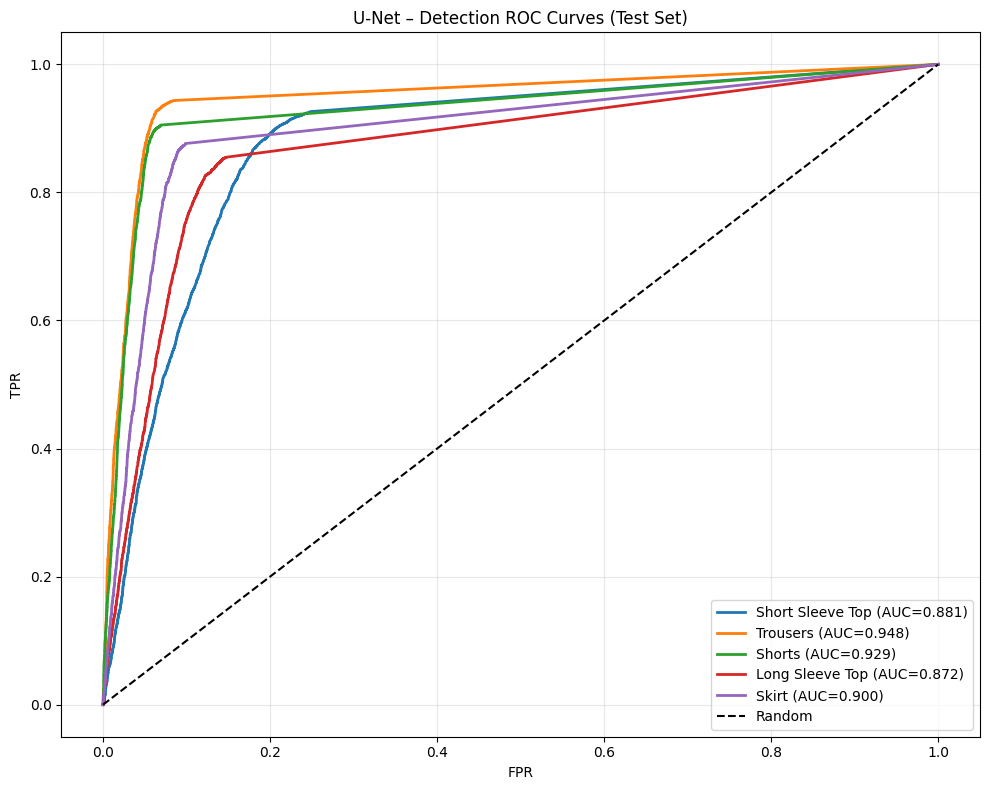

In [30]:
# Detection ROC Curves + F1
n_cls = len(category_names)

print("\n" + "="*60)
print("DETECTION: Per-Class P / R / F1 / AUC")
print("="*60)
aucs = []
for cls in range(1, n_cls + 1):
    yt = np.array(y_true[cls])
    ys = np.array(y_scores[cls])
    yp = np.array(y_pred[cls])
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
    roc_auc = sk_auc(*roc_curve(yt, ys)[:2]) if yt.sum() > 0 else float('nan')
    aucs.append(roc_auc)
    print(f"  {idx_to_name[cls]:<20}: P={p:.4f} R={r:.4f} F1={f1:.4f} AUC={roc_auc:.4f}")

yt_all = np.column_stack([y_true[cls]  for cls in range(1, n_cls + 1)])
yp_all = np.column_stack([y_pred[cls]  for cls in range(1, n_cls + 1)])
mp, mr, mf1, _ = precision_recall_fscore_support(yt_all, yp_all, average='macro', zero_division=0)
up, ur, uf1, _ = precision_recall_fscore_support(yt_all, yp_all, average='micro', zero_division=0)
print("-"*60)
print(f"  Macro P={mp:.4f} R={mr:.4f} F1={mf1:.4f}")
print(f"  Micro P={up:.4f} R={ur:.4f} F1={uf1:.4f}")
print(f"  Mean AUC = {np.nanmean(aucs):.4f}")

plt.figure(figsize=(10, 8))
for cls in range(1, n_cls + 1):
    yt = np.array(y_true[cls])
    ys = np.array(y_scores[cls])
    if yt.sum() == 0: continue
    fpr, tpr, _ = roc_curve(yt, ys)
    plt.plot(fpr, tpr, lw=2, label=f'{idx_to_name[cls]} (AUC={aucs[cls-1]:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('U-Net – Detection ROC Curves (Test Set)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{DRIVE_SAVE}/unet_roc.png", dpi=150)
plt.show()

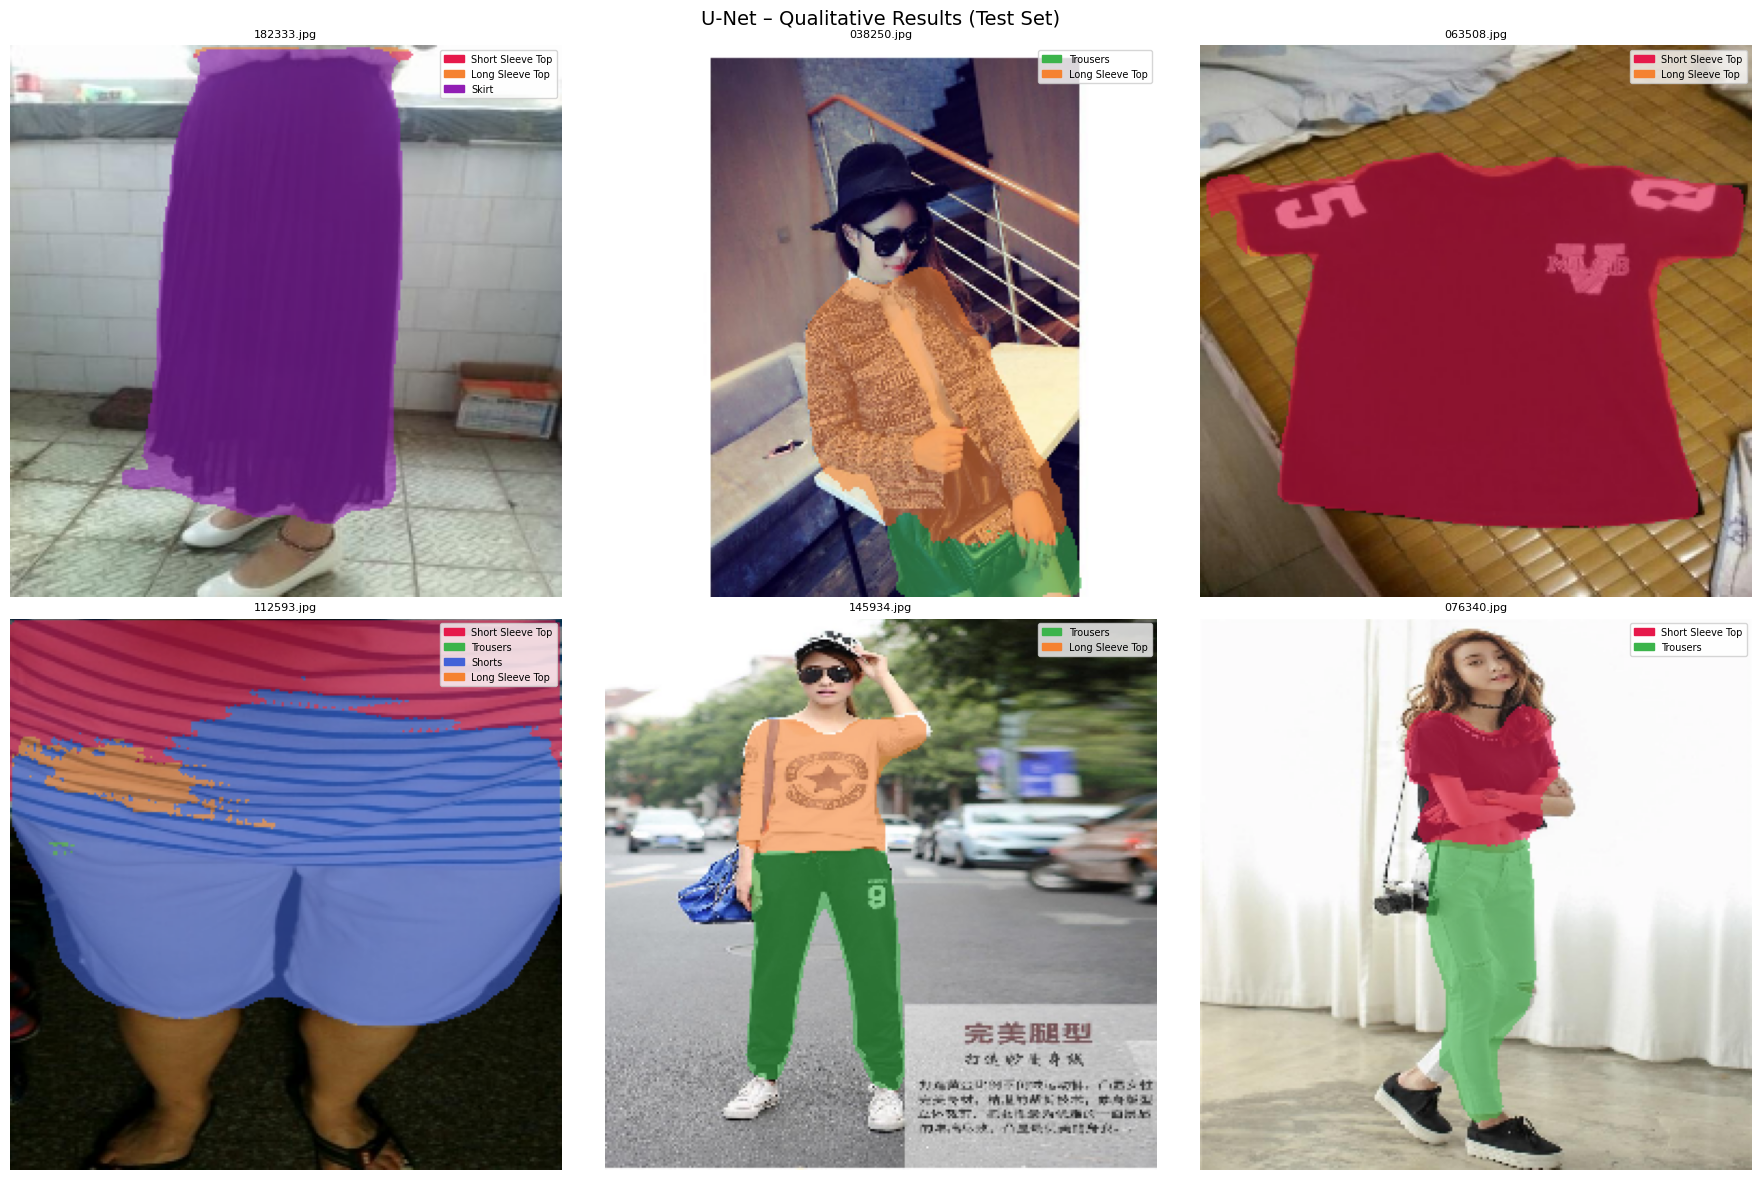

In [31]:
# =========================================================
# Qualitative Visualisation
# =========================================================
PALETTE = ['#000000','#e6194b','#3cb44b','#4363d8','#f58231','#911eb4']

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

indices = random.sample(range(len(test_ds)), min(6, len(test_ds)))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

eval_model.eval()
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        img_t, mask_gt, img_name = test_ds[idx]
        with autocast("cuda"):
            logits = eval_model(img_t.unsqueeze(0).to(device))
        pred = logits.argmax(1).squeeze(0).cpu().numpy()

        # De-normalise for display
        img_disp = (img_t * IMAGENET_STD + IMAGENET_MEAN).clamp(0,1)
        img_np   = (img_disp.permute(1,2,0).numpy() * 255).astype(np.uint8).copy()

        # Colour overlay
        for c in range(1, NUM_CLASSES):
            color = np.array(to_rgba(PALETTE[c])[:3]) * 255
            mask  = pred == c
            img_np[mask] = (img_np[mask] * 0.4 + color * 0.6).astype(np.uint8)

        ax.imshow(img_np)
        patches = [mpatches.Patch(color=PALETTE[c], label=idx_to_name[c])
                   for c in range(1, NUM_CLASSES)
                   if (pred == c).sum() > 0]
        ax.legend(handles=patches, fontsize=7, loc='upper right')
        ax.set_title(img_name, fontsize=8); ax.axis('off')

plt.suptitle('U-Net – Qualitative Results (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{DRIVE_SAVE}/unet_qualitative.png", dpi=150)
plt.show()

In [ ]:
import shutil

DRIVE_SAVE = "/kaggle/working/VR_Mini_Project-1"
shutil.copy(
    "/kaggle/input/datasets/sasank2035/unet-weights-scratch/unet_scratch.pth",
    f"{DRIVE_SAVE}/unet_scratch.pth"
)

In [ ]:
# =========================================================
# Scratch model evaluation for comparison
# =========================================================
print("\n=== EVALUATING U-NET SCRATCH ===")
scratch_eval = UNetResNet34(NUM_CLASSES, pretrained=False).to(device)
scratch_eval.load_state_dict(torch.load(f"{DRIVE_SAVE}/unet_scratch.pth", map_location=device))
if n_gpus > 1:
    scratch_eval = nn.DataParallel(scratch_eval)
scratch_eval.eval()
evaluate_semantic(scratch_eval, test_loader, device, NUM_CLASSES, split_name="Test (Scratch)")